In [1]:
import pandas as pd

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

cancer = load_breast_cancer()

data_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
data_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [2]:
lr_clf = LogisticRegression(solver='liblinear')
knn_clf = KNeighborsClassifier(n_neighbors=8)

vo_clf = VotingClassifier( estimators=[('LR',lr_clf),('KNN',knn_clf)] , voting='soft' )

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, 
                                                    test_size=0.2 , random_state= 42)

vo_clf.fit(X_train , y_train)
pred = vo_clf.predict(X_test)
print(accuracy_score(y_test , pred))



0.9649122807017544


In [3]:
classifiers = [lr_clf, knn_clf]
for classifier in classifiers:
    classifier.fit(X_train , y_train)
    pred = classifier.predict(X_test)
    print(classifier.__class__.__name__, accuracy_score(y_test, pred))

LogisticRegression 0.956140350877193
KNeighborsClassifier 0.956140350877193


In [4]:
def get_new_feature_name_df(old_feature_name_df):
    feature_dup_df = pd.DataFrame(
        data=old_feature_name_df.groupby('column_name').cumcount(),
        columns=['dup_cnt']
    )
    feature_dup_df = feature_dup_df.reset_index()
    new_feature_name_df = pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')
    
    new_feature_name_df['column_name'] = new_feature_name_df.apply(
        lambda x: f"{x['column_name']}_{x['dup_cnt']}" if x['dup_cnt'] > 0 else x['column_name'], 
        axis=1
    )
    
    new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)
    return new_feature_name_df

In [6]:
import csv
import pandas as pd

ACTION_MAP = {"WALKING": 1, "WALKING_UPSTAIRS": 2, "WALKING_DOWNSTAIRS": 3, "SITTING": 4, "STANDING": 5, "LAYING": 6}

def get_human_dataset():
    train_file = "./data/human_activity_train.csv"
    test_file = "./data/human_activity_test.csv"

    with open(train_file, encoding="utf-8") as f:
        header = next(csv.reader(f))
        feature_name_org = header[:-2]

    feature_name_df = pd.DataFrame({
        "column_index": range(1, len(feature_name_org) + 1),
        "column_name": feature_name_org
    })

    new_feature_name_df = get_new_feature_name_df(feature_name_df)

    feature_name = new_feature_name_df.iloc[:, 1].values.tolist()
    col_names = feature_name + ["subject", "action"]

    train_df = pd.read_csv(train_file, header=0, names=col_names)
    test_df = pd.read_csv(test_file, header=0, names=col_names)

    X_train = train_df[feature_name]
    X_test = test_df[feature_name]

    y_train = train_df[["action"]].replace(ACTION_MAP)
    y_test = test_df[["action"]].replace(ACTION_MAP)

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = get_human_dataset()
print("X_train:", X_train.shape, "X_test:", X_test.shape,
      "y_train:", y_train.shape, "y_test:", y_test.shape)   

X_train: (7352, 561) X_test: (2947, 561) y_train: (7352, 1) y_test: (2947, 1)


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

X_train, X_test, y_train, y_test = get_human_dataset()

rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train , y_train.astype(int))
pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test.astype(int), pred)
print(accuracy)

c:\Users\KDS-22\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.9256871394638616


In [12]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':[100],
    'max_depth' : [6, 8, 10, 12], 
    'min_samples_leaf' : [8, 12, 18 ],
    'min_samples_split' : [8, 16, 20]
}

rf_clf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_cv = GridSearchCV(rf_clf , param_grid=params , cv=2, n_jobs=-1 )
grid_cv.fit(X_train , y_train.astype(int))

print(grid_cv.best_params_)
print(grid_cv.best_score_)

c:\Users\KDS-22\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


{'max_depth': 12, 'min_samples_leaf': 8, 'min_samples_split': 8, 'n_estimators': 100}
0.9189336235038085


In [16]:
rf_clf1 = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=8, \
                                 min_samples_split=8, random_state=42)
rf_clf1.fit(X_train , y_train.astype(int))
pred = rf_clf1.predict(X_test)
print(accuracy_score(y_test.astype(int) , pred))

c:\Users\KDS-22\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.9256871394638616


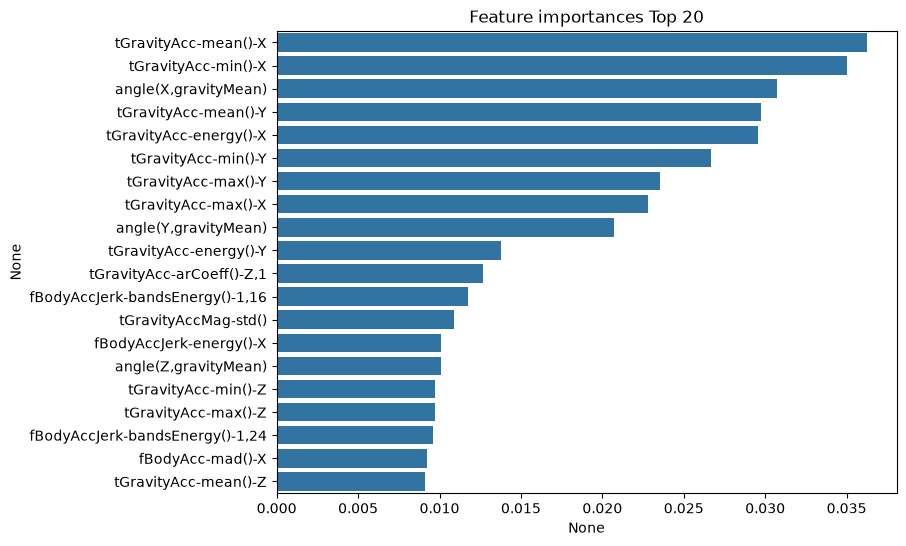

<Figure size 640x480 with 0 Axes>

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

ftr_importances_values = rf_clf1.feature_importances_
ftr_importances = pd.Series(ftr_importances_values,index=X_train.columns  )
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]

plt.figure(figsize=(8,6))
plt.title('Feature importances Top 20')
sns.barplot(x=ftr_top20 , y = ftr_top20.index)
fig1 = plt.gcf()
plt.show()
plt.draw()

In [21]:
from sklearn.ensemble import GradientBoostingClassifier
import time

X_train, X_test, y_train, y_test = get_human_dataset()

start_time = time.time()

gb_clf = GradientBoostingClassifier(random_state=42)
gb_clf.fit(X_train , y_train.astype(int))
gb_pred = gb_clf.predict(X_test)
gb_accuracy = accuracy_score(y_test.astype(int), gb_pred)

print(gb_accuracy)
print(time.time() - start_time)

0.9389209365456397
482.42832922935486
